# Merging crossover points from laser altimetry and radar

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs

data_dir = "../data/"
df_icesat = gpd.read_parquet(f"{data_dir}x_points_explode.parquet")
df_xopr = gpd.read_parquet(f"{data_dir}intersections.parquet")

df_icesat = df_icesat.to_crs(epsg=3031)
df_xopr_pts = df_xopr.set_geometry("intersection_geometry").to_crs(epsg=3031)

df_merged = gpd.sjoin_nearest(
    df_icesat,
    df_xopr_pts,
    how="inner",
    max_distance=10,
    distance_col="dist_m"
)
print(f"Matched points: {len(df_merged)}")


Matched points: 106


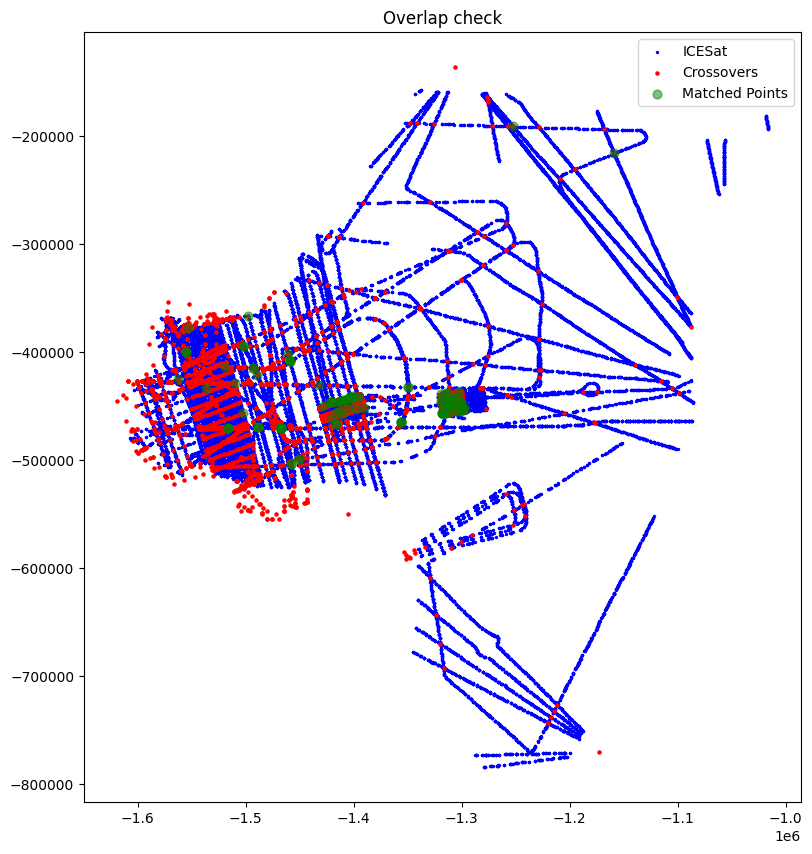

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df_icesat.plot(ax=ax, color="blue", markersize=2, label="ICESat")
df_xopr.set_geometry("intersection_geometry").plot(ax=ax, color="red", markersize=5, label="Crossovers")
df_merged.plot(ax=ax, color="green", markersize=40, label="Matched Points", alpha=0.5)
plt.legend()
plt.title("Overlap check")
plt.show()


In [54]:
print(df_merged.head(5))
print(df_merged.shape)

# save to geoparquet
df_merged.to_parquet(f"{data_dir}icesat-radar-merged_points.parquet")

                                 geometry  index_right                  id_1  \
216  POINT Z (-1416146.349 -466316.074 0)         3104  Data_20100103_02_016   
216  POINT Z (-1416146.349 -466316.074 0)         2982  Data_20100103_02_009   
216   POINT Z (-1349906.98 -431988.902 0)          405  Data_20091102_02_009   
216  POINT Z (-1349915.862 -431993.493 0)         5959  Data_20141121_06_020   
607  POINT Z (-1404991.942 -453088.286 0)         2263  Data_20100103_01_006   

                     id_2         collection_1         collection_2  \
216  Data_20100103_02_009   2009_Antarctica_TO   2009_Antarctica_TO   
216  Data_20100103_02_016   2009_Antarctica_TO   2009_Antarctica_TO   
216  Data_20141121_05_007  2009_Antarctica_DC8  2014_Antarctica_DC8   
216  Data_20141121_05_007  2014_Antarctica_DC8  2014_Antarctica_DC8   
607  Data_20100112_01_005   2009_Antarctica_TO   2009_Antarctica_TO   

                                                geom_1  \
216  LINESTRING (-1421480.508 -467